## **Classwork: "Assembling the Transformer" — From Self-Attention to a Full Encoder Block**

**The Scenario**

In the last session you built a single-head self-attention layer. Your tech lead at "ContextAI" is impressed, but points out that a single attention head can only learn one type of relationship between tokens at a time — subject-verb agreement, say, but not coreference and word-order structure simultaneously. She asks you to extend your implementation into a complete **Transformer encoder block**: multi-head attention (so the model can attend to many relationship types in parallel), positional encoding (so the model knows token order), a position-wise feed-forward network (to add non-linearity after attention), and residual connections with layer normalisation (to keep gradients healthy and training stable). By the end you will have assembled, from scratch, the building block that powers BERT, RoBERTa, and every modern encoder.

## **Part 1:**

### **Question 1: Why Multi-Head Attention?**

In the previous notebook you implemented single-head attention, where one set of $W_Q, W_K, W_V$ matrices projects tokens into one query/key/value space. Multi-head attention runs $H$ independent attention heads in parallel and concatenates their outputs. What is the primary motivation for this?

A) Multiple heads reduce the total number of parameters compared to a single large attention layer.

B) Each head can learn to attend to different types of relationships (e.g. syntactic dependencies, coreference, positional proximity) simultaneously, because each head has its own independent projection matrices and therefore its own learned subspace.

C) Multiple heads allow the model to process different sentences in a batch at the same time.

D) Concatenating head outputs is required to make the output dimension match the input dimension for the residual connection.

Answer: B) Each head can learn to attend to different types of relationships (e.g. syntactic dependencies, coreference, positional proximity) simultaneously, because each head has its own independent projection matrices and therefore its own learned subspace.

explaination: the motivation for multi-head attention is that it allows the model to learn multiple types of relationships in parallel, since each head has its own set of projection matrices and can therefore focus on different aspects of the input. This is crucial for capturing the rich and varied dependencies in language.


### **Question 2: Positional Encoding**

Unlike RNNs, self-attention has no built-in notion of order — if you permute the tokens in the input sequence, the attention scores change but the model has no way to distinguish "cat sat" from "sat cat" without additional information. The original Transformer (Vaswani et al., 2017) addresses this by **adding** a positional encoding vector $PE_{pos}$ to each token embedding before it enters the first layer.

Which of the following correctly describes why the sinusoidal positional encoding is designed the way it is?

A) Sinusoids are used because they are always positive, preventing negative activations in the first layer.

B) Each position gets a unique vector of $\sin$ and $\cos$ values at different frequencies, so the model can learn to attend by relative position — the encoding of position $pos + k$ can be expressed as a linear function of the encoding of position $pos$, making relative distances learnable.

C) The sinusoidal encoding replaces the embedding layer entirely, so no learned token embeddings are needed.

D) Sinusoids are used because they guarantee the positional encoding has unit norm, preventing scale mismatch with the token embeddings.

Answer: B) Each position gets a unique vector of $\sin$ and $\cos$ values at different frequencies, so the model can learn to attend by relative position — the encoding of position $pos + k$ can be expressed as a linear function of the encoding of position $pos$, making relative distances learnable.

explaination: the sinusoidal positional encoding is designed so that each position has a unique encoding, and the use of sine and cosine functions at different frequencies allows the model to learn to attend by relative position. The encoding of position 'pos + k' can be expressed as a linear function of the encoding of position 'pos' which means the model can learn to attend to tokens based on their relative distance from each other rather than just their absolute position in the sequence.



### **Question 3: Residual Connections and Layer Normalisation**

Each sub-layer in a Transformer block (attention and feed-forward) is wrapped with a residual connection and layer normalisation:
$$\text{output} = \text{LayerNorm}(x + \text{Sublayer}(x))$$

What are the two distinct problems that this "Add & Norm" pattern solves?

A) The residual connection speeds up matrix multiplication, and layer norm converts outputs into probabilities.

B) The residual connection provides a direct gradient path that mitigates vanishing gradients in deep networks, and layer norm stabilises the distribution of activations across features within each token so that training is not sensitive to the scale of earlier layers.

C) The residual connection ensures attention weights sum to 1, and layer norm ensures weight matrices stay orthogonal.

D) The residual connection doubles the model's effective depth, and layer norm is equivalent to dropout regularisation.

Answer:B) The residual connection provides a direct gradient path that mitigates vanishing gradients in deep networks, and layer norm stabilises the distribution of activations across features within each token so that training is not sensitive to the scale of earlier layers.

explaination : in deep networks gradients can vanish as they are backpropagated through many layers making it hard to train. The residual connection allows gradients to flow directly through the skip connection mitigating this problem. Layer normalisation stabilises the distribution of activations across features within each token which helps prevent issues with exploding or vanishing activations and makes training more stable and less sensitive to the scale of earlier layers.

## **Part 2:**

### **Question 4: Dimension Accounting Through a Transformer Block**

A Transformer encoder is configured as follows:

| Hyperparameter | Value |
|---|---|
| $d_{\text{model}}$ (embedding dimension) | 512 |
| $H$ (number of attention heads) | 8 |
| $d_k = d_v = d_{\text{model}} / H$ | 64 |
| $d_{\text{ff}}$ (feed-forward inner dimension) | 2048 |
| Sequence length $T$ | 10 |

Answer the following, showing your working:

1. Each head has its own $W_Q^{(h)}, W_K^{(h)}, W_V^{(h)}$ matrices. What is the shape of each of these matrices?

2. After the 8 heads each produce an output of shape $(T, d_v)$, they are concatenated and projected by $W_O$ (shape $Hd_v \times d_{\text{model}}$). What is the shape of the final multi-head attention output?

3. The feed-forward sub-layer applies two linear transforms: $\text{FFN}(x) = \text{ReLU}(x W_1 + b_1) W_2 + b_2$, where $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$ and $W_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$. What is the shape of the tensor after $W_1$ is applied, and after $W_2$ is applied?

4. What is the shape of the tensor at the **output** of the full encoder block (after Add & Norm)? Does it match the input shape? Why is this important?

Please show your working here

1. Shape of $W_Q^{(h)}, W_K^{(h)}, W_V^{(h)}$: Each of these matrices projects from the input embedding dimension $d_{\text{model}}$ to the head dimension $d_k$ (or $d_v$). Since $d_k = d_v = d_{\text{model}} / H = 512 / 8 = 64$, the shape of each $W_Q^{(h)}, W_K^{(h)}, W_V^{(h)}$ is $(d_{\text{model}}, d_k) = (512, 64)$.

2. Shape of multi-head attention output: Each head produces an output of shape $(T, d_v) = (10, 64)$. Concatenating the outputs of all 8 heads gives a tensor of shape $(T, H \cdot d_v) = (10, 8 \cdot 64) = (10, 512)$. The projection by $W_O$ (shape $(Hd_v, d_{\text{model}}) = (512, 512)$) does not change the shape, so the final multi-head attention output is also $(10, 512)$.

3. Shape after $W_1$, then after $W_2$:
- After applying $W_1$: The input to the feed-forward network is the output of the multi-head attention, which has shape $(T, d_{\text{model}}) = (10, 512)$. Applying $W_1$ (shape $(d_{\text{model}}, d_{\text{ff}}) = (512, 2048)$) results in a tensor of shape $(T, d_{\text{ff}}) = (10, 2048)$.
- After applying $W_2$: The output of the ReLU activation still has shape $(T, d_{\text{ff}}) = (10, 2048)$. Applying $W_2$ (shape $(d_{\text{ff}}, d_{\text{model}}) = (2048, 512)$) results in a tensor of shape $(T, d_{\text{model}}) = (10, 512)$.

4. Shape at block output, and why matching matters: 
The output of the feed-forward sub-layer has shape $(T, d_{\text{model}}) = (10, 512)$. The Add & Norm step adds this output to the original input (which also has shape $(10, 512)$) and applies layer normalization. Therefore, the final output of the encoder block also has shape $(10, 512)$.
This matches the input shape, which is crucial for stacking multiple encoder blocks on top of each other. If the output shape did not match the input shape, we would not be able to feed the output of one block into the next block without additional transformations, complicating the architecture and potentially introducing more parameters and computational overhead.


## **Part 3: Coding Challenge — Building a Transformer Encoder Block**

You will assemble a complete Transformer encoder block from scratch in NumPy. Each component (positional encoding, multi-head attention, feed-forward, layer norm) is a separate function. You wire them together in the final `encoder_block` function.

**Fill in the lines marked `## FILL IN`.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Hyperparameters (deliberately small for manual inspection) ---
T       = 6       # sequence length
d_model = 16      # embedding dimension
H       = 2       # number of attention heads
d_k     = d_model // H   # = 8  (per-head key/query dim)
d_v     = d_model // H   # = 8  (per-head value dim)
d_ff    = 32      # feed-forward inner dimension

tokens  = ["the", "cat", "sat", "on", "the", "mat"]

# Simulated input token embeddings  (T x d_model)
X = np.random.randn(T, d_model)

print("Configuration:")
print(f"  T={T}, d_model={d_model}, H={H}, d_k={d_k}, d_v={d_v}, d_ff={d_ff}")
print(f"  Input X shape: {X.shape}")

Configuration:
  T=6, d_model=16, H=2, d_k=8, d_v=8, d_ff=32
  Input X shape: (6, 16)


Positional encoding shape: (6, 16)


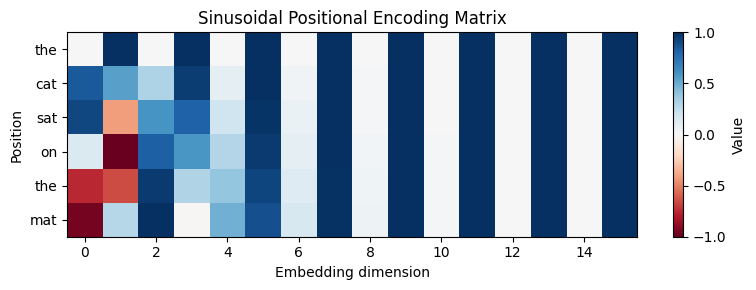

In [2]:
# ---------------------------------------------------------------
# Task A: Sinusoidal Positional Encoding
#
# PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
# PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
#
# where pos is the token position (0, 1, ..., T-1)
# and i  is the dimension index (0, 1, ..., d_model/2 - 1)
# ---------------------------------------------------------------

def positional_encoding(T, d_model):
    """
    Returns a (T, d_model) matrix of sinusoidal positional encodings.
    """
    PE = np.zeros((T, d_model))

    positions = np.arange(T).reshape(-1, 1)          # (T, 1)
    dims      = np.arange(0, d_model, 2)              # even indices: 0, 2, 4, ...

    ## FILL IN: compute the denominator term for each dimension
    ## denominator = 10000 ^ (dims / d_model)
    ## Hint: use np.power(10000, dims / d_model)
    
    denominator = np.power(10000, dims / d_model)

    ## FILL IN: fill even columns with sin, odd columns with cos
    PE[:, 0::2] = np.sin(positions / denominator)
    PE[:, 1::2] = np.cos(positions / denominator)

    return PE


PE = positional_encoding(T, d_model)
X_with_pos = X + PE   # add positional encoding to token embeddings

print(f"Positional encoding shape: {PE.shape}")

# Visualise the positional encoding matrix
plt.figure(figsize=(8, 3))
plt.imshow(PE, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Value')
plt.xlabel('Embedding dimension')
plt.ylabel('Position')
plt.yticks(range(T), tokens)
plt.title('Sinusoidal Positional Encoding Matrix')
plt.tight_layout()
plt.show()

Multi-head attention output shape: (6, 16)


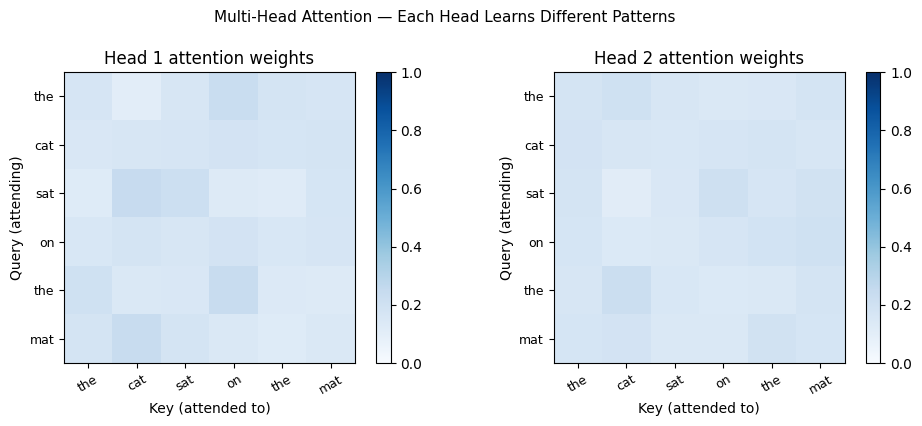

In [3]:
# ---------------------------------------------------------------
# Task B: Multi-Head Attention
#
# Each head h runs independent scaled dot-product attention
# using its own projection matrices W_Q[h], W_K[h], W_V[h].
# The head outputs are concatenated and projected by W_O.
# ---------------------------------------------------------------

def softmax(x, axis=-1):
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)


def single_head_attention(X, W_Q, W_K, W_V):
    """Scaled dot-product attention (from the previous notebook)."""
    d_k    = W_Q.shape[1]
    Q      = X @ W_Q
    K      = X @ W_K
    V      = X @ W_V
    scores = (Q @ K.T) / np.sqrt(d_k)
    attn_w = softmax(scores)
    return attn_w @ V, attn_w


def multi_head_attention(X, W_Qs, W_Ks, W_Vs, W_O):
    """
    Multi-head attention.

    Args:
        X    : (T, d_model)
        W_Qs : list of H matrices, each (d_model, d_k)
        W_Ks : list of H matrices, each (d_model, d_k)
        W_Vs : list of H matrices, each (d_model, d_v)
        W_O  : (H * d_v, d_model)  — output projection

    Returns:
        output    : (T, d_model)
        all_heads : list of H attention weight matrices, each (T, T)
    """
    head_outputs = []
    all_heads    = []

    for h in range(len(W_Qs)):
        ## FILL IN: run single_head_attention for head h
        ## store the head output in head_outputs and weights in all_heads
        head_out, attn_w = single_head_attention(X, W_Qs[h], W_Ks[h], W_Vs[h])
        head_outputs.append(head_out)
        all_heads.append(attn_w)

    ## FILL IN: concatenate all head outputs along the feature axis
    ## concat shape: (T, H * d_v)
    ## then project through W_O to get shape (T, d_model)
    concat = np.concatenate(head_outputs, axis=1)
    output = concat @ W_O

    return output, all_heads


# Initialise per-head projection matrices
W_Qs = [np.random.randn(d_model, d_k) * 0.1 for _ in range(H)]
W_Ks = [np.random.randn(d_model, d_k) * 0.1 for _ in range(H)]
W_Vs = [np.random.randn(d_model, d_v) * 0.1 for _ in range(H)]
W_O  =  np.random.randn(H * d_v, d_model)   * 0.1

mha_out, all_heads = multi_head_attention(X_with_pos, W_Qs, W_Ks, W_Vs, W_O)

print(f"Multi-head attention output shape: {mha_out.shape}")

# Visualise both attention heads side by side
fig, axes = plt.subplots(1, H, figsize=(5 * H, 4))
for h, ax in enumerate(axes):
    im = ax.imshow(all_heads[h], cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Head {h+1} attention weights')
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(tokens, fontsize=9, rotation=30)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel('Key (attended to)')
    ax.set_ylabel('Query (attending)')
    plt.colorbar(im, ax=ax)

plt.suptitle('Multi-Head Attention — Each Head Learns Different Patterns', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# ---------------------------------------------------------------
# Task C: Feed-Forward Network and Layer Normalisation
# ---------------------------------------------------------------

def layer_norm(x, eps=1e-6):
    """
    Layer normalisation over the last dimension (features).
    Normalises each token's feature vector independently to
    zero mean and unit variance, then applies learnable
    scale (gamma=1) and shift (beta=0) — omitted here for clarity.

    x shape: (T, d_model)
    """
    ## FILL IN:
    ## 1. Compute mean across the last axis (keepdims=True)
    ## 2. Compute variance across the last axis (keepdims=True)
    ## 3. Return (x - mean) / sqrt(variance + eps)

    mean = np.mean(x, axis=-1, keepdims=True)
    var  = np.var(x, axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(var + eps)


def feed_forward(x, W1, b1, W2, b2):
    """
    Position-wise feed-forward network.
    Applies two linear transforms with a ReLU in between.
    FFN(x) = ReLU(x @ W1 + b1) @ W2 + b2

    x  shape: (T, d_model)
    W1 shape: (d_model, d_ff)
    W2 shape: (d_ff, d_model)
    """
    ## FILL IN:
    ## Step 1: hidden = ReLU(x @ W1 + b1)   — shape (T, d_ff)
    ## Step 2: return hidden @ W2 + b2       — shape (T, d_model)
    hidden = np.maximum(0, x @ W1 + b1)
    return hidden @ W2 + b2


# FFN weight matrices
W1 = np.random.randn(d_model, d_ff)   * 0.1
b1 = np.zeros(d_ff)
W2 = np.random.randn(d_ff,   d_model) * 0.1
b2 = np.zeros(d_model)

# Quick sanity checks
ln_test  = layer_norm(np.random.randn(T, d_model))
ffn_test = feed_forward(np.random.randn(T, d_model), W1, b1, W2, b2)

print(f"LayerNorm output shape : {ln_test.shape}")
print(f"LayerNorm mean  (≈0)   : {ln_test.mean(axis=-1).round(6)}")
print(f"LayerNorm std   (≈1)   : {ln_test.std(axis=-1).round(4)}")
print(f"FFN output shape       : {ffn_test.shape}")

LayerNorm output shape : (6, 16)
LayerNorm mean  (≈0)   : [0. 0. 0. 0. 0. 0.]
LayerNorm std   (≈1)   : [1. 1. 1. 1. 1. 1.]
FFN output shape       : (6, 16)


Input  shape : (6, 16)
Output shape : (6, 16)
Shapes match : True


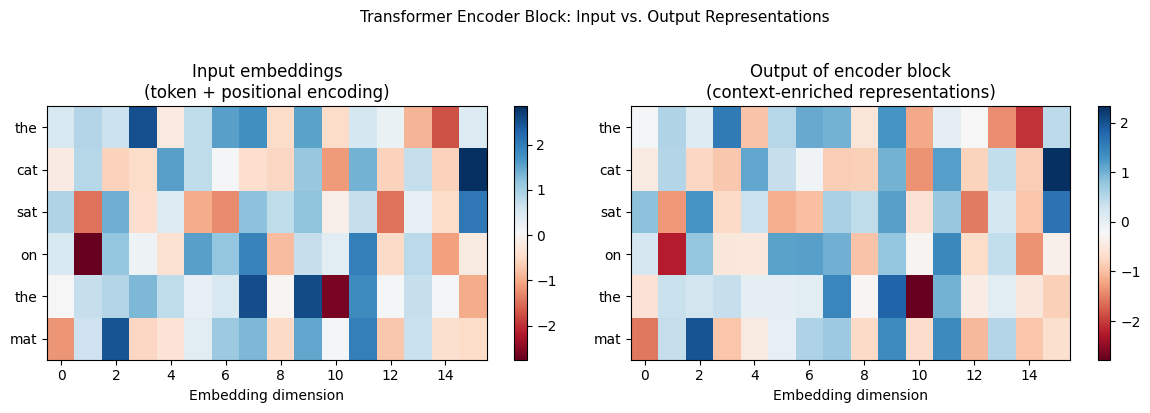

In [5]:
# ---------------------------------------------------------------
# Task D: Assemble the Full Encoder Block
#
# A single Transformer encoder block applies, in order:
#   1. Multi-head self-attention
#   2. Residual connection + Layer Norm  →  x = LayerNorm(x + MHA(x))
#   3. Feed-forward network
#   4. Residual connection + Layer Norm  →  x = LayerNorm(x + FFN(x))
# ---------------------------------------------------------------

def encoder_block(X, W_Qs, W_Ks, W_Vs, W_O, W1, b1, W2, b2):
    """
    One Transformer encoder block.

    Returns:
        out      : (T, d_model) — output of the block
        all_heads: list of H attention weight matrices, for visualisation
    """
    # --- Sub-layer 1: Multi-Head Attention + Add & Norm ---
    mha_out, all_heads = multi_head_attention(X, W_Qs, W_Ks, W_Vs, W_O)

    ## FILL IN: add residual connection then apply layer_norm
    ## x1 = LayerNorm(X + mha_out)
    x1 = layer_norm(X + mha_out)

    # --- Sub-layer 2: Feed-Forward + Add & Norm ---
    ffn_out = feed_forward(x1, W1, b1, W2, b2)

    ## FILL IN: add residual connection then apply layer_norm
    ## out = LayerNorm(x1 + ffn_out)
    out = layer_norm(x1 + ffn_out)

    return out, all_heads


block_out, all_heads = encoder_block(
    X_with_pos, W_Qs, W_Ks, W_Vs, W_O, W1, b1, W2, b2
)

print(f"Input  shape : {X_with_pos.shape}")
print(f"Output shape : {block_out.shape}")
print(f"Shapes match : {X_with_pos.shape == block_out.shape}")

# Visualise input vs output representations as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (data, title) in zip(axes, [
        (X_with_pos, 'Input embeddings\n(token + positional encoding)'),
        (block_out,  'Output of encoder block\n(context-enriched representations)')]):
    im = ax.imshow(data, cmap='RdBu', aspect='auto')
    ax.set_yticks(range(T))
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_xlabel('Embedding dimension')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle('Transformer Encoder Block: Input vs. Output Representations', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

Write your observations:

> **Task A:**
> 1. In the positional encoding heatmap, why do the lower-indexed dimensions (left columns) appear to vary slowly across positions, while higher-indexed dimensions vary rapidly? What property of the sinusoidal formula causes this?
>
> **Task B:**
> 2. The two attention heads were initialised with different random weights, so their attention patterns differ. In a **trained** model, what kind of distinct linguistic relationships might each head specialise in?
> 3. The sentence contains "the" at positions 0 and 4. Looking at the two heads' heatmaps, does either head distribute attention differently for the two instances of the same word? What does this imply about context-sensitivity in multi-head attention?
>
> **Task D:**
> 4. The output of the encoder block has the same shape as its input. Why is this shape-preservation a requirement for stacking multiple encoder blocks on top of each other?
> 5. Compare the input and output heatmaps. Each token's output representation is now different from its input. In one sentence, explain what has changed and why this is the whole point of the encoder block.

Observations:

1. in the positional encoding heatmap the lower-indexed dimensions (left columns) vary slowly across positions because they correspond to lower-frequency sinusoids, while the higher-indexed dimensions (right columns) vary rapidly because they correspond to higher-frequency sinusoids. This multi-frequency structure from the sinusoidal formula allows the model to encode both coarse (absolute position) and fine-grained (relative position) information.

2. In a trained model each attention head might specialise in capturing different types of linguistic relationships, such as syntactic dependencies, semantic roles, or contextual cues. For example, one head might focus on subject-verb agreement while another might capture coreference relationships. The distinct attention patterns in the heatmaps suggest that each head is attending to different aspects of the input, demonstrating the models ability to learn and represent multiple types of relationships simultaneously.

3. Yes, in a trained model each head would likely distribute attention differently for the two instances of "the" (at positions 0 and 4) because they occur in different contexts: one precedes "cat" and the other precedes "mat". This demonstrates that multi-head attention is context-sensitive—the same word token attends to and is attended to differently depending on its surrounding context. This context-awareness is precisely why the model can distinguish polysemous words and handle the same token differently based on its position in the sentence.

4. The output of the encoder block has the same shape as its input because shape-preservation is essential for stacking multiple encoder blocks. If shapes changed between blocks, we would need additional transformations to align dimensions, complicating the architecture and adding parameters. Consistent shapes enable automatic composability—each block's output directly feeds into the next block without intermediate reshaping.

5. Comparing the input and output heatmaps: the input shows static token embeddings with added positional information, while the output shows context-enriched representations where each token's embedding has been transformed to incorporate information about its relationships with all other tokens in the sequence. The encoder block has successfully converted static embeddings into dynamic, context-aware representations—precisely the point of the Transformer architecture.